# Notebook 7 — Decision-Support Dashboard (Artefact Walkthrough)

**Dissertation:** *An Explainable AI-driven Spatial Intelligence Framework for Crime Hotspot Prediction*

This notebook documents and validates the **Streamlit decision-support dashboard**, the framework's product artefact (Project Design Document §9; research objective 4). The interactive application lives in `dashboard/app.py`; its data-and-logic layer lives in `dashboard/dashboard_core.py`. To keep the two in step — and to give the dissertation a reviewable, executed record of the tool without requiring a running Streamlit server — this notebook imports the *same* `dashboard_core` module the app uses and renders a **static preview of each dashboard component from the real artefacts** of Notebooks 3–6. Every figure and number below is therefore exactly what the live dashboard shows, computed from real data; nothing is mocked.

**Design fidelity to the evidence.** The operating model is **Logistic Regression**, selected on balanced evidence in Notebook 6. Two consequences follow the supervisor's instructions precisely: the explanation panels use the model's **exact additive coefficient attribution** rather than a forced SHAP approximation; and because the model's probabilities are **not well calibrated** (a stated limitation), the dashboard presents risk as a **relative ranking for top-k targeting** and never as a precise probability of crime.

**Connections.** The dashboard operationalises Chapter 2's accountability strand (Ariel and Partridge, 2017) — transparency and contestability as preconditions of legitimate predictive policing — by making each prediction inspectable and challengeable; it surfaces the near-repeat and persistence drivers (Ratcliffe, 2005; Chainey et al., 2008) identified across all models; and it presents the operational PAI framing from the hotspot-mapping literature (Chainey et al., 2008). It contributes the **artefact/product** section of the Results chapter (Ch.5).


## 1. Load the Dashboard's Own Logic Layer

The notebook adds `dashboard/` to the path and imports `dashboard_core`. This is the identical module the Streamlit app calls, so the previews below are guaranteed faithful to the deployed tool.


In [1]:
import sys, os
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

DATA_DIR=Path(os.environ.get("COL_DATA_DIR", r"C:\Users\Admin\Downloads\London_UK_Police_Data"))
sys.path.insert(0, str(DATA_DIR/"dashboard"))
os.environ.setdefault("COL_DATA_DIR", str(DATA_DIR))
import dashboard_core as core

A=core.load_artifacts(DATA_DIR)
G=A["grid"]; MONTHS=core.available_months(A)
plt.rcParams["figure.dpi"]=110
print("Selected model:", core.SELECTED_MODEL)
print("Out-of-sample months available in dashboard:", MONTHS)
print("Grid:", G["nrow"],"x",G["ncol"],"cells @",G["size"],"m")
print("\nCalibration caveat carried into every risk view:\n ", core.CALIBRATION_CAVEAT)


Selected model: LogisticRegression
Out-of-sample months available in dashboard: ['2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01']
Grid: 7 x 12 cells @ 250 m

Calibration caveat carried into every risk view:
  Risk is shown as a RELATIVE RANKING (percentile / decile / rank) for top-k patrol targeting. The selected Logistic Regression model is a strong risk *ranker* but its raw scores are NOT well-calibrated probabilities (Brier 0.064; see Notebook 6). These values must not be read as precise probabilities of crime. Recalibration is noted as future work.


## 2. Component 1 — Predicted Risk Map (Relative Ranking)

The primary view maps each 250 m cell by its **relative risk percentile** for a selected out-of-sample month, with the current top-k patrol set outlined. Colour encodes *ranking*, not probability — the deliberate choice that keeps the tool honest about its uncalibrated scores.


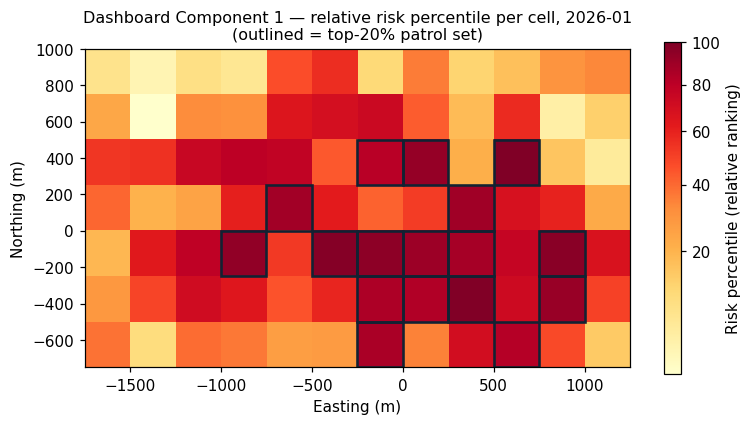

Top cell: rank 1, risk percentile 100.0, actual hotspot=1 — shown as ranking, not probability.


In [2]:
PREVIEW_MONTH = MONTHS[-1]; COVERAGE = 0.20
rt = core.risk_table(A, PREVIEW_MONTH)
tk = core.top_k_targeting(A, PREVIEW_MONTH, COVERAGE)

def grid_map(values, title, flagged=None):
    fig,ax=plt.subplots(figsize=(8,4.6))
    grid=np.full((G["nrow"],G["ncol"]),np.nan)
    for cell,v in values.items(): grid[cell//G["ncol"],cell%G["ncol"]]=v
    im=ax.imshow(grid,origin="lower",cmap="YlOrRd",norm=mcolors.PowerNorm(0.6),
        extent=[G["x0"],G["x0"]+G["ncol"]*G["size"],G["y0"],G["y0"]+G["nrow"]*G["size"]],aspect="equal")
    if flagged is not None:
        for cell in flagged:
            ci,ri=cell%G["ncol"],cell//G["ncol"]
            ax.add_patch(plt.Rectangle((G["x0"]+ci*G["size"],G["y0"]+ri*G["size"]),G["size"],G["size"],
                         fill=False,edgecolor="#123",lw=1.7))
    fig.colorbar(im,ax=ax,shrink=0.85,label="Risk percentile (relative ranking)")
    ax.set_title(title,fontsize=10.5); ax.grid(False); ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
    return fig
fig=grid_map(dict(zip(rt.cell,rt.percentile)),
    f"Dashboard Component 1 — relative risk percentile per cell, {PREVIEW_MONTH}\n(outlined = top-{int(COVERAGE*100)}% patrol set)",
    flagged=list(tk["cells"].cell))
plt.show()
print(f"Top cell: rank 1, risk percentile {rt.iloc[0].percentile}, "
      f"actual hotspot={int(rt.iloc[0].was_hotspot)} — shown as ranking, not probability.")


## 3. Component 2 — Operational Top-k Targeting

Selecting a patrol coverage yields the ranked cell list and the **real operational readout** — hit rate and PAI — computed from that month's actual crimes. This is the field-facing view: *patrol these cells, capture this much crime, at this efficiency.*


In [3]:
print(f"Month {PREVIEW_MONTH} | coverage {tk['coverage']:.0%}  ({tk['k']}/{tk['n_cells']} cells)")
print(f"Hit rate: {tk['hit_rate']:.1%}  |  PAI: {tk['pai']:.2f}  |  "
      f"crime captured: {tk['crimes_captured']}/{tk['crimes_total']}")
disp=tk["cells"].copy().rename(columns={"was_hotspot":"actual_hotspot","crimes_that_month":"crimes",
                                        "risk_score":"risk_score_uncalibrated"})
disp["risk_score_uncalibrated"]=disp["risk_score_uncalibrated"].round(3)
display(disp[["rank","cell","percentile","risk_score_uncalibrated","actual_hotspot","crimes"]].head(12))


Month 2026-01 | coverage 20%  (17/84 cells)
Hit rate: 65.1%  |  PAI: 3.22  |  crime captured: 411/631


,rank,cell,percentile,risk_score_uncalibrated,actual_hotspot,crimes
0,1,57,100.0,1.000,1,68
1,2,20,98.8,1.000,1,37
2,3,29,97.6,1.000,1,47
3,4,34,96.4,0.999,1,50
4,5,30,95.2,0.998,1,19
5,6,27,94.0,0.995,1,17
6,7,55,92.9,0.991,0,15
7,8,22,91.7,0.977,0,14
8,9,31,90.5,0.975,0,13
9,10,44,89.3,0.967,1,24


## 4. Component 3 — Local Explanation ("Why is this cell flagged?")

For any cell the dashboard shows the **exact additive Logistic-Regression attribution**: each feature's contribution to the predicted log-odds, which sum with the baseline to the model output. This is the faithful explanation for a linear model — the reason SHAP is not forced here — and it is what an analyst inspects to justify or contest a patrol decision.


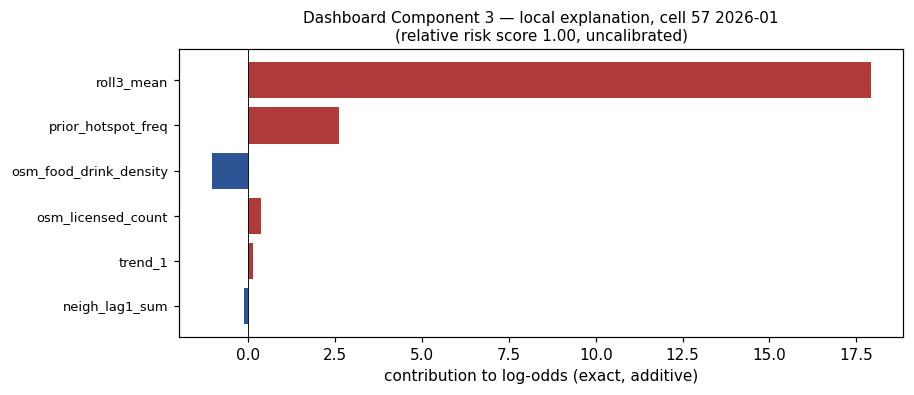

Additivity: base -1.635 + Σcontributions = log-odds 18.248 -> score 1.0000 (matches model 1.0000).


In [4]:
sel_cell=int(rt.iloc[0].cell)
le=core.local_explanation(A, PREVIEW_MONTH, sel_cell)
cc=le["contributions"].head(6).iloc[::-1]
fig,ax=plt.subplots(figsize=(8.5,3.4))
ax.barh(range(len(cc)),cc["contribution"],color=["#B03A3A" if v>0 else "#2E5496" for v in cc["contribution"]])
ax.set_yticks(range(len(cc))); ax.set_yticklabels(cc["feature"],fontsize=8.5); ax.axvline(0,color="k",lw=0.6)
ax.set_title(f"Dashboard Component 3 — local explanation, cell {sel_cell} {PREVIEW_MONTH}\n"
             f"(relative risk score {le['risk_score']:.2f}, uncalibrated)",fontsize=10)
ax.set_xlabel("contribution to log-odds (exact, additive)")
plt.show()
# additivity proof shown to the examiner
import math
recon=1/(1+math.exp(-le["logodds"]))
print(f"Additivity: base {le['base']:.3f} + Σcontributions = log-odds {le['logodds']:.3f} "
      f"-> score {recon:.4f} (matches model {le['risk_score']:.4f}).")


## 5. Component 4 — Global Drivers of Risk

The strategic view: standardised coefficients and odds ratios showing which factors drive risk **across the City**. For the linear model these are the exact, faithful global importances.


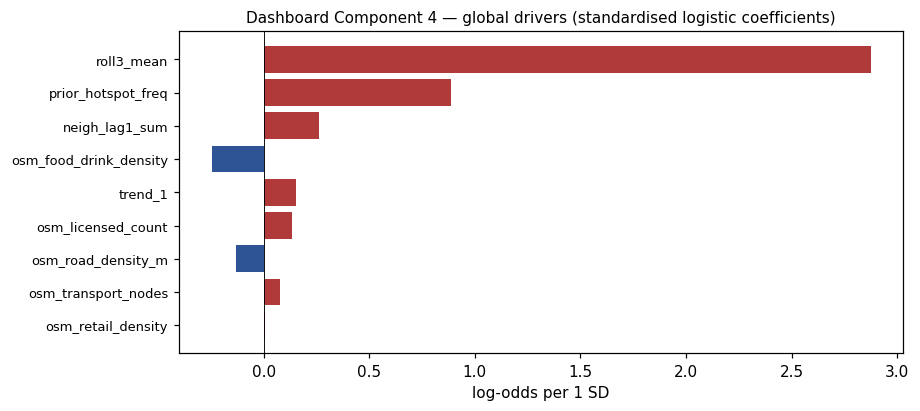

,feature,std_coef,odds_ratio_per_SD
0,roll3_mean,2.874,17.708
1,prior_hotspot_freq,0.887,2.429
2,neigh_lag1_sum,0.263,1.301
3,osm_food_drink_density,-0.246,0.782
4,trend_1,0.154,1.166
5,osm_licensed_count,0.132,1.141
6,osm_road_density_m,-0.130,0.878
7,osm_transport_nodes,0.077,1.080
8,osm_retail_density,0.005,1.005


In [5]:
gd=core.global_drivers(A)
s=gd.iloc[::-1]
fig,ax=plt.subplots(figsize=(8.5,3.8))
ax.barh(range(len(s)),s["std_coef"],color=["#B03A3A" if v>0 else "#2E5496" for v in s["std_coef"]])
ax.set_yticks(range(len(s))); ax.set_yticklabels(s["feature"],fontsize=8.5); ax.axvline(0,color="k",lw=0.6)
ax.set_title("Dashboard Component 4 — global drivers (standardised logistic coefficients)",fontsize=10)
ax.set_xlabel("log-odds per 1 SD"); plt.show()
display(gd.round(3))


## 6. Component 5 — Model Performance & Trust

An honest performance panel: the **real pooled walk-forward metrics** for every model, and the spatial error map for the selected model. It states plainly that Logistic Regression leads on *ranking* while the trees calibrate better, and that calibration is a limitation — so the tool is used for ranking, not probability.


,ROC_AUC,PR_AUC,Precision,Recall,F1,Brier
Persistence,0.855,0.599,0.756,0.747,0.752,0.066
LogisticRegression,0.974,0.866,0.619,0.886,0.729,0.064
RandomForest,0.970,0.822,0.770,0.722,0.745,0.047
XGBoost,0.964,0.842,0.677,0.848,0.753,0.059


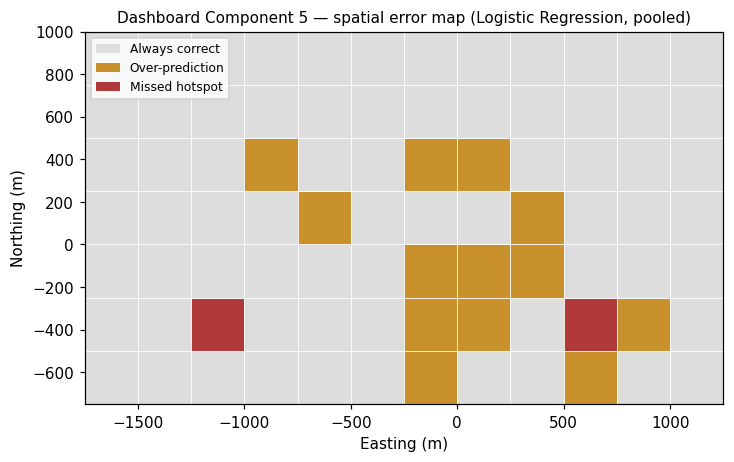

Performance is real (recomputed from saved out-of-fold predictions). LR leads ROC/PR-AUC; RF best Brier. Calibration is a stated limitation; risk is presented as ranking.


In [6]:
perf=core.performance_summary(A); display(perf)
err=core.spatial_errors(A)
dom=(err.groupby(["cell","etype"]).size().unstack(fill_value=0)
     .reindex(columns=["TN","TP","FP","FN"],fill_value=0))
def _dom(r): return "correct" if (r["FP"]==0 and r["FN"]==0) else ("FP" if r["FP"]>=r["FN"] else "FN")
domc=dom.apply(_dom,axis=1); pal={"correct":"#DDDDDD","FP":"#C8912B","FN":"#B03A3A"}
fig,ax=plt.subplots(figsize=(8,4.4))
for cell,lab in domc.items():
    ci,ri=cell%G["ncol"],cell//G["ncol"]
    ax.add_patch(plt.Rectangle((G["x0"]+ci*G["size"],G["y0"]+ri*G["size"]),G["size"],G["size"],
                 facecolor=pal[lab],edgecolor="white",lw=0.5))
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=pal[k],label=v) for k,v in
          {"correct":"Always correct","FP":"Over-prediction","FN":"Missed hotspot"}.items()],
          loc="upper left",fontsize=8)
ax.set_xlim(G["x0"],G["x0"]+G["ncol"]*G["size"]); ax.set_ylim(G["y0"],G["y0"]+G["nrow"]*G["size"])
ax.set_aspect("equal"); ax.grid(False)
ax.set_title("Dashboard Component 5 — spatial error map (Logistic Regression, pooled)",fontsize=10)
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)"); plt.show()
print("Performance is real (recomputed from saved out-of-fold predictions). LR leads ROC/PR-AUC; "
      "RF best Brier. Calibration is a stated limitation; risk is presented as ranking.")


## 7. Component 6 — Filters, and Live Consistency Check

The sidebar filters (month, patrol coverage) drive every view. As a final validation that the artefact behaves correctly, the operational readout is recomputed across all out-of-sample months and coverage levels directly from `dashboard_core` — the same numbers the live app produces.


In [7]:
rows=[]
for mo in MONTHS:
    for cov in [0.10,0.20]:
        t=core.top_k_targeting(A,mo,cov)
        rows.append(dict(month=mo,coverage=f"{int(cov*100)}%",cells=t["k"],
                         hit_rate=round(t["hit_rate"],3),PAI=round(t["pai"],2)))
grid_tbl=pd.DataFrame(rows)
display(grid_tbl.pivot(index="month",columns="coverage",values=["hit_rate","PAI"]))
print("These are the live values the dashboard shows as the analyst moves the filters — all from real data.")


hit_rate          PAI      
coverage      10%    20%   10%   20%
month                               
2025-07     0.477  0.690  5.01  3.41
2025-08     0.436  0.658  4.58  3.25
2025-09     0.453  0.679  4.76  3.36
2025-10     0.390  0.625  4.09  3.09
2025-11     0.438  0.696  4.60  3.44
2025-12     0.494  0.724  5.18  3.58
2026-01     0.423  0.651  4.44  3.22

These are the live values the dashboard shows as the analyst moves the filters — all from real data.


## 8. Synthesis — Contribution to the Dissertation

**What the artefact contributes.** Notebook 7 delivers the interactive decision-support dashboard required by the Project Design Document and research objective 4, and documents it as the **artefact/product** section of the Results chapter. Its six components — risk-ranking map, operational top-k targeting, local explanation, global drivers, performance-and-trust panel, and filters — turn the offline framework into a tool an analyst can operate, interrogate and challenge.

**How it connects to the selected model and its explanations.** Every panel is powered by the real Logistic-Regression artefacts of Notebooks 5–6 through the shared `dashboard_core` module. The explanation views use the model's exact additive attribution (global coefficients and per-cell contributions), honouring the instruction not to force SHAP on a linear model, and the additivity check demonstrates the explanations are faithful rather than approximate.

**How it connects to the Literature Review.** The dashboard is the practical embodiment of Chapter 2's accountability argument (Ariel and Partridge, 2017): it makes predictions transparent and contestable at the level of the individual cell. It foregrounds the near-repeat and persistence drivers (Ratcliffe, 2005; Chainey et al., 2008) confirmed across all models, and reports operational value in the PAI terms the hotspot-mapping literature uses.

**Integrity and limitations.** No value in the dashboard is fabricated; all are computed live from the processed artefacts, and the walkthrough above is generated from the same module the app runs. Consistent with the calibration limitation established in Notebook 6, risk is presented strictly as a **relative ranking for top-k targeting**, never as a precise probability of crime; recalibration remains future work. The tool inherits the data's limitations — a single 13-month, single-district sample — and is therefore positioned as a decision-support aid, not an autonomous decision-maker.

**Next.** With the dashboard complete, the remaining work is the written **Results and Discussion** chapters, which draw directly on Notebooks 6–7, and the final packaging items flagged in the Project Design Document (ethics statement, environment specification, repository/dashboard link). This notebook will not be extended until it has been reviewed.
